### **A2C LUNAR LANDER PyTorch using autograd**

**REINFORCE vs A2C — what changes:**

| | REINFORCE | A2C |
|---|---|---|
| Network | 1 head (policy) | Actor + critic networks |
| Loss | Policy-gradient loss weighted by return | Actor loss + critic loss + entropy bonus |
| Baseline | Per-batch mean of returns | Learned value function `V(s)` |
| What gets multiplied with `∇ log π(a|s)` | Normalized return `G` | Advantage `A = G − V(s)` |
| Training | One policy-gradient update | Manual PyTorch optimization steps |

**Why a custom training step.** A2C has two learning objectives: the actor learns which action to take, while the critic learns how good a state is. In PyTorch this is naturally written with explicit forward passes, losses, `backward()`, and `optimizer.step()`.

**What we expect.** A2C should solve LunarLander noticeably faster and more reliably than REINFORCE. Same environment difficulty, but the learned baseline reduces much of the variance.

**This model has improvements**

  - Vectorized environments: N_ENVS = 8, collecting experience from multiple LunarLanders in parallel.
  - n-step bootstrapped returns: update every fixed rollout instead of waiting for full episodes.
  - GAE: Generalized Advantage Estimation, lower-variance advantage estimates.
  - Observation normalization: stabilizes learning from LunarLander’s mixed-scale state variables.
  - Reward scaling: keeps critic targets numerically manageable.

In [1]:
import sys
import os
import time
import random
import warnings
from pathlib import Path

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Optional: redirect stderr if some libraries print too much noise
# sys.stderr = open("err.txt", "w")

Device: cuda


In [2]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected — training on CPU is fine for this notebook.")

PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GB10


### Hyperparameters

Mostly the same as the REINFORCE notebook. The new ones are the loss-coefficient knobs (`ENTROPY_COEF`, actor LR, critic LR), which are standard actor-critic tuning parameters.

In [3]:
TOTAL_TIMESTEPS = 2_000_000
N_ENVS = 8
ROLLOUT_STEPS = 20
learning_rate = 2.5e-4
ROLLING_WINDOW = 100         # LunarLander official benchmark window
solved_threshold = 200       # mean(last 100) >= 200
MAX_STEPS_PER_EPISODE = 1000

# A2C-specific knobs
GAMMA = 0.99                 # discount factor
GAE_LAMBDA = 0.95            # smoother bootstrapped advantages
VALUE_COEF = 0.5             # critic loss weight
ENTROPY_COEF = 0.01          # entropy bonus weight
REWARD_SCALE = 0.01          # keeps critic targets numerically small
GRAD_CLIP_NORM = 0.5         # stabilizes updates


### The A2C agent

This PyTorch version uses two separate networks:

1. **Actor network** — receives the state and outputs **logits** for the action distribution.
2. **Critic network** — receives the state and outputs the scalar value estimate `V(s)`.
3. **Training step** — first update the critic to predict Monte Carlo returns, then update the actor using the standardized advantage.

The actor does **not** output softmax probabilities directly. It outputs logits, and `torch.distributions.Categorical(logits=...)` handles the softmax internally in a numerically stable way.

In [4]:
class RunningMeanStd:
    def __init__(self, shape, epsilon=1e-4):
        self.mean = np.zeros(shape, dtype=np.float64)
        self.var = np.ones(shape, dtype=np.float64)
        self.count = epsilon

    def update(self, x):
        x = np.asarray(x, dtype=np.float64)
        batch_mean = x.mean(axis=0)
        batch_var = x.var(axis=0)
        batch_count = x.shape[0]
        self._update_from_moments(batch_mean, batch_var, batch_count)

    def _update_from_moments(self, batch_mean, batch_var, batch_count):
        delta = batch_mean - self.mean
        total_count = self.count + batch_count
        new_mean = self.mean + delta * batch_count / total_count
        m_a = self.var * self.count
        m_b = batch_var * batch_count
        m_2 = m_a + m_b + np.square(delta) * self.count * batch_count / total_count
        self.mean = new_mean
        self.var = m_2 / total_count
        self.count = total_count

    def normalize(self, x):
        return np.clip((x - self.mean) / np.sqrt(self.var + 1e-8), -10.0, 10.0).astype(np.float32)


class ActorCriticNet(nn.Module):
    def __init__(self, state_size, action_size, hidden=128):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(state_size, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.actor = nn.Linear(hidden, action_size)   # logits, not probabilities
        self.critic = nn.Linear(hidden, 1)             # scalar value V(s)

        self.apply(self._init_weights)
        nn.init.orthogonal_(self.actor.weight, gain=0.01)
        nn.init.constant_(self.actor.bias, 0.0)
        nn.init.orthogonal_(self.critic.weight, gain=1.0)
        nn.init.constant_(self.critic.bias, 0.0)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, nn.Linear):
            nn.init.orthogonal_(module.weight, gain=np.sqrt(2))
            nn.init.constant_(module.bias, 0.0)

    def forward(self, x):
        features = self.shared(x)
        logits = self.actor(features)
        value = self.critic(features).squeeze(-1)
        return logits, value


class A2CAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.obs_rms = RunningMeanStd(shape=(state_size,))
        self.model = ActorCriticNet(state_size, action_size).to(device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate)

    def normalize_obs(self, states, update=False):
        states = np.asarray(states, dtype=np.float32)
        if update:
            batch = states.reshape(-1, self.state_size)
            self.obs_rms.update(batch)
        return self.obs_rms.normalize(states)

    def get_action(self, state):
        """Sample an action from the current stochastic policy."""
        state = self.normalize_obs(state, update=False)
        state_t = torch.as_tensor(state, dtype=torch.float32, device=device)
        if state_t.ndim == 2 and state_t.shape[0] == 1:
            state_t = state_t.squeeze(0)

        self.model.eval()
        with torch.no_grad():
            logits, _ = self.model(state_t)
            dist = Categorical(logits=logits)
            action = dist.sample()

        return int(action.item())

    def get_action_greedy(self, state):
        """Deterministic action: choose the action with the largest logit."""
        state = self.normalize_obs(state, update=False)
        state_t = torch.as_tensor(state, dtype=torch.float32, device=device)
        if state_t.ndim == 2 and state_t.shape[0] == 1:
            state_t = state_t.squeeze(0)

        self.model.eval()
        with torch.no_grad():
            logits, _ = self.model(state_t)
            action = torch.argmax(logits, dim=-1)

        return int(action.item())

    def act_batch(self, states):
        states = self.normalize_obs(states, update=True)
        states_t = torch.as_tensor(states, dtype=torch.float32, device=device)
        logits, values = self.model(states_t)
        dist = Categorical(logits=logits)
        actions = dist.sample()
        log_probs = dist.log_prob(actions)
        entropy = dist.entropy()
        return actions, log_probs, entropy, values

    def value_batch(self, states):
        states = self.normalize_obs(states, update=False)
        states_t = torch.as_tensor(states, dtype=torch.float32, device=device)
        _, values = self.model(states_t)
        return values

    def update(self, log_probs, entropies, values, advantages, returns):
        log_probs = torch.stack(log_probs).reshape(-1)
        entropies = torch.stack(entropies).reshape(-1)
        values = torch.stack(values).reshape(-1)
        advantages = torch.stack(advantages).reshape(-1)
        returns = torch.stack(returns).reshape(-1)

        policy_advantages = (advantages - advantages.mean()) / (advantages.std(unbiased=False) + 1e-8)
        policy_loss = -(log_probs * policy_advantages.detach()).mean()
        value_loss = 0.5 * (returns - values).pow(2).mean()
        entropy = entropies.mean()
        loss = policy_loss + VALUE_COEF * value_loss - ENTROPY_COEF * entropy

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.model.parameters(), GRAD_CLIP_NORM)
        self.optimizer.step()

        return (
            float(policy_loss.detach().cpu().item()),
            float(value_loss.detach().cpu().item()),
            float(entropy.detach().cpu().item()),
        )


### Training loop

Same shape as the REINFORCE loop. The main differences:

- We get back actor, critic, and entropy losses from `train_model()`.
- No `-100` reward hack and no per-episode normalization of returns. The critic handles that role.
- The PyTorch update is explicit: `zero_grad()`, `backward()`, and `step()`.

In [5]:
start_time = time.time()

def make_env(rank):
    def thunk():
        env = gym.make("LunarLander-v3")
        env.action_space.seed(SEED + rank)
        return env
    return thunk

envs = gym.vector.SyncVectorEnv([make_env(i) for i in range(N_ENVS)])
state_size = envs.single_observation_space.shape[0]
action_size = int(envs.single_action_space.n)

agent = A2CAgent(state_size, action_size)

obs, _ = envs.reset(seed=SEED)
scores, rolling_avg_rewards = [], []
loss_history = {"actor": [], "critic": [], "entropy": []}
episode_returns = np.zeros(N_ENVS, dtype=np.float32)
episode_lengths = np.zeros(N_ENVS, dtype=np.int32)
updates = TOTAL_TIMESTEPS // (N_ENVS * ROLLOUT_STEPS)
solved = False

for update_idx in range(1, updates + 1):
    log_probs, entropies, values = [], [], []
    rewards, dones = [], []

    agent.model.train()

    for _ in range(ROLLOUT_STEPS):
        actions_t, log_prob_t, entropy_t, value_t = agent.act_batch(obs)
        actions = actions_t.detach().cpu().numpy()

        next_obs, reward, terminated, truncated, _ = envs.step(actions)
        done = np.logical_or(terminated, truncated)

        log_probs.append(log_prob_t)
        entropies.append(entropy_t)
        values.append(value_t)
        rewards.append(torch.as_tensor(reward * REWARD_SCALE, dtype=torch.float32, device=device))
        dones.append(torch.as_tensor(done, dtype=torch.float32, device=device))

        episode_returns += reward
        episode_lengths += 1

        for env_i, is_done in enumerate(done):
            if is_done:
                scores.append(float(episode_returns[env_i]))
                rolling_avg = np.mean(scores[-ROLLING_WINDOW:])
                rolling_avg_rewards.append(rolling_avg)

                print(
                    f"Ep {len(scores):4d}  R: {episode_returns[env_i]:+8.2f}  "
                    f"Roll{ROLLING_WINDOW}: {rolling_avg:+8.2f}  "
                    f"Steps: {episode_lengths[env_i]:4d}"
                )

                episode_returns[env_i] = 0.0
                episode_lengths[env_i] = 0

                if len(scores) >= ROLLING_WINDOW and rolling_avg >= solved_threshold:
                    print(f"\nSolved at episode {len(scores)}! Rolling{ROLLING_WINDOW} = {rolling_avg:.2f}")
                    solved = True

        obs = next_obs

        if solved:
            break

    with torch.no_grad():
        next_values = agent.value_batch(obs)

    advantages, returns = [], []
    gae = torch.zeros(N_ENVS, dtype=torch.float32, device=device)
    for step in reversed(range(len(rewards))):
        next_non_terminal = 1.0 - dones[step]
        next_value = next_values if step == len(rewards) - 1 else values[step + 1].detach()
        delta = rewards[step] + GAMMA * next_value * next_non_terminal - values[step].detach()
        gae = delta + GAMMA * GAE_LAMBDA * next_non_terminal * gae
        advantages.insert(0, gae)
        returns.insert(0, gae + values[step].detach())

    losses = agent.update(log_probs, entropies, values, advantages, returns)
    loss_history["actor"].append(losses[0])
    loss_history["critic"].append(losses[1])
    loss_history["entropy"].append(losses[2])

    if update_idx % 250 == 0:
        timesteps = update_idx * N_ENVS * ROLLOUT_STEPS
        last_roll = np.mean(scores[-ROLLING_WINDOW:]) if scores else float("nan")
        print(
            f"Update {update_idx:5d}/{updates}  Steps: {timesteps:7d}  "
            f"Episodes: {len(scores):4d}  Roll{ROLLING_WINDOW}: {last_roll:+8.2f}  "
            f"L_a: {losses[0]:+7.3f}  L_c: {losses[1]:8.4f}  H: {losses[2]:.3f}"
        )

    if solved:
        break

envs.close()
print(f"\nTraining completed in {(time.time() - start_time) / 60:.2f} minutes")


Ep    1  R:  -111.40  Roll100:  -111.40  Steps:   63
Ep    2  R:  -130.05  Roll100:  -120.72  Steps:   88
Ep    3  R:   -78.94  Roll100:  -106.80  Steps:   93
Ep    4  R:  -383.06  Roll100:  -175.86  Steps:   98
Ep    5  R:  -197.63  Roll100:  -180.22  Steps:  101
Ep    6  R:  -204.61  Roll100:  -184.28  Steps:  101
Ep    7  R:  -113.00  Roll100:  -174.10  Steps:  117
Ep    8  R:  -107.49  Roll100:  -165.77  Steps:  126
Ep    9  R:  -210.28  Roll100:  -170.72  Steps:   75
Ep   10  R:   -66.22  Roll100:  -160.27  Steps:   66
Ep   11  R:   -78.49  Roll100:  -152.83  Steps:   70
Ep   12  R:   -11.44  Roll100:  -141.05  Steps:   86
Ep   13  R:  -335.28  Roll100:  -155.99  Steps:  106
Ep   14  R:  -361.76  Roll100:  -170.69  Steps:   95
Ep   15  R:  -108.92  Roll100:  -166.57  Steps:  134
Ep   16  R:  -225.10  Roll100:  -170.23  Steps:  119
Ep   17  R:  -190.06  Roll100:  -171.40  Steps:  124
Ep   18  R:  -115.55  Roll100:  -168.29  Steps:  101
Ep   19  R:  -289.38  Roll100:  -174.67  Steps

### Training curves

Two plots:

1. **Reward over episodes** — same as REINFORCE. The rolling average should be visibly smoother and climb faster.
2. **Losses over episodes** — actor, critic, and entropy. These are useful A2C diagnostics.

**What to look for:**

- **Actor loss** should stay near zero. It can be positive or negative — it is not a "smaller is better" loss like cross-entropy. What matters is that it is bounded and not exploding.
- **Critic loss** should decrease over time. If it grows, your critic is failing to predict returns.
- **Entropy** should decrease slowly from `ln(action_size) ≈ 1.39` toward 0. If it crashes to zero in the first 50 episodes, the policy collapsed too early — raise `ENTROPY_COEF`. If it stays at 1.39 forever, the policy never commits — lower it.

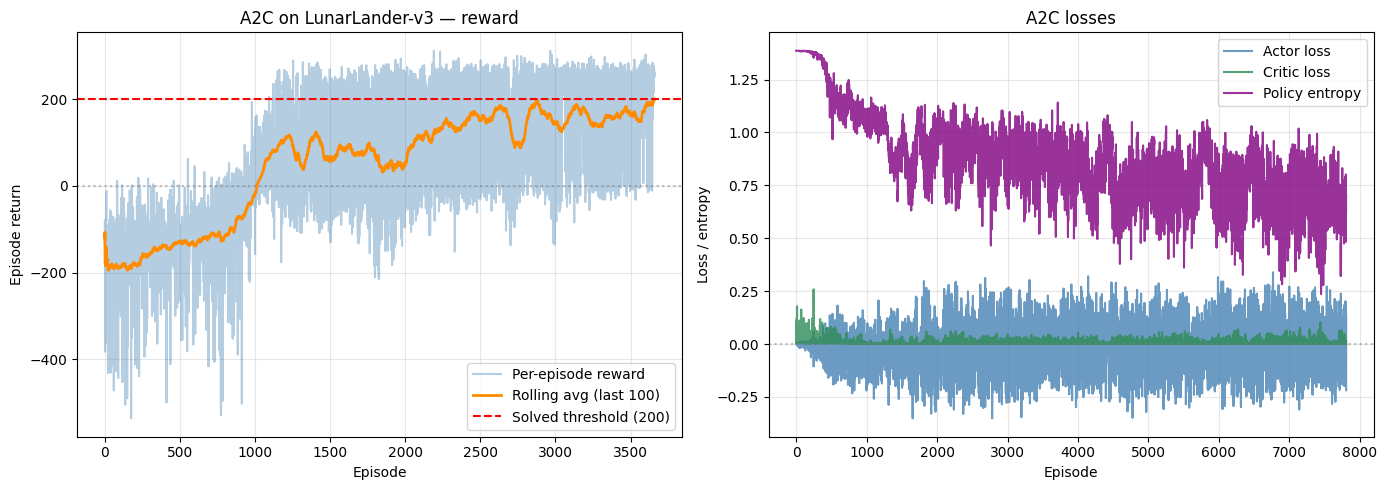

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: reward curve
ax = axes[0]
ax.plot(scores, color='steelblue', alpha=0.4, label='Per-episode reward')
ax.plot(rolling_avg_rewards, color='darkorange', linewidth=2,
        label=f'Rolling avg (last {ROLLING_WINDOW})')
ax.axhline(y=solved_threshold, color='red', linestyle='--',
           label=f'Solved threshold ({solved_threshold})')
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
ax.set_title('A2C on LunarLander-v3 — reward')
ax.set_xlabel('Episode')
ax.set_ylabel('Episode return')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

# Right: loss curves
ax = axes[1]
ax.plot(loss_history['actor'],   color='steelblue', label='Actor loss', alpha=0.8)
ax.plot(loss_history['critic'],  color='seagreen',  label='Critic loss', alpha=0.8)
ax.plot(loss_history['entropy'], color='purple',    label='Policy entropy', alpha=0.8)
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
ax.set_title('A2C losses')
ax.set_xlabel('Episode')
ax.set_ylabel('Loss / entropy')
ax.legend(loc='best')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Evaluation

We evaluate **stochastically** by default — sampling actions from the policy, same as during training. The motivation: a partially-converged policy is often better with the random noise than without, because the noise lets the agent occasionally escape states where the argmax action is wrong. If you train to convergence (rolling average ≥ 200 consistently), greedy evaluation should match or beat stochastic; if you don't, it often won't. We expose both options.

In [7]:
# Choose your evaluation mode here.
USE_GREEDY_EVAL = False

env = gym.make("LunarLander-v3")
test_rewards = []

for e_test in range(20):
    state, _ = env.reset(seed=10_000 + e_test)
    state = np.reshape(state, [1, state_size]).astype(np.float32)

    total_reward = 0.0
    steps = 0

    while True:
        action = agent.get_action_greedy(state) if USE_GREEDY_EVAL else agent.get_action(state)

        next_state, reward, terminated, truncated, _ = env.step(action)
        next_state = np.reshape(next_state, [1, state_size]).astype(np.float32)

        total_reward += reward
        state = next_state
        steps += 1

        if terminated or truncated:
            break

    test_rewards.append(total_reward)

    mode = "greedy" if USE_GREEDY_EVAL else "stochastic"
    print(f"Test {e_test+1:2d}/20  [{mode:>10s}]  Reward: {total_reward:+8.2f}  Steps: {steps:4d}")

env.close()

print()
print(
    f"Mean test reward: {np.mean(test_rewards):+.2f}  "
    f"(std {np.std(test_rewards):.2f}, "
    f"min {np.min(test_rewards):+.1f}, max {np.max(test_rewards):+.1f})"
)


Test  1/20  [stochastic]  Reward:  +220.82  Steps:  426
Test  2/20  [stochastic]  Reward:  +281.54  Steps:  258
Test  3/20  [stochastic]  Reward:  +248.37  Steps:  294
Test  4/20  [stochastic]  Reward:  +261.17  Steps:  238
Test  5/20  [stochastic]  Reward:  +275.51  Steps:  218
Test  6/20  [stochastic]  Reward:   +25.27  Steps:  189
Test  7/20  [stochastic]  Reward:  +245.89  Steps:  448
Test  8/20  [stochastic]  Reward:  +125.21  Steps: 1000
Test  9/20  [stochastic]  Reward:   +40.83  Steps:  178
Test 10/20  [stochastic]  Reward:  +272.89  Steps:  322
Test 11/20  [stochastic]  Reward:  +260.76  Steps:  331
Test 12/20  [stochastic]  Reward:  +245.85  Steps:  511
Test 13/20  [stochastic]  Reward:  +280.72  Steps:  385
Test 14/20  [stochastic]  Reward:   +10.05  Steps:  187
Test 15/20  [stochastic]  Reward:  +241.72  Steps:  494
Test 16/20  [stochastic]  Reward:  +267.41  Steps:  222
Test 17/20  [stochastic]  Reward:  +250.72  Steps:  174
Test 18/20  [stochastic]  Reward:  +259.72  Step

### Render an episode as a GIF

In [10]:
env = gym.make("LunarLander-v3", render_mode="rgb_array")
frames = []

state, _ = env.reset(seed=20_000)
state = np.reshape(state, [1, state_size]).astype(np.float32)
tot_rewards = 0.0

for step in range(MAX_STEPS_PER_EPISODE):
    action = agent.get_action_greedy(state) if USE_GREEDY_EVAL else agent.get_action(state)

    next_state, reward, terminated, truncated, _ = env.step(action)
    frames.append(env.render())

    next_state = np.reshape(next_state, [1, state_size]).astype(np.float32)

    tot_rewards += reward
    state = next_state

    if terminated or truncated:
        print(f"Episode reward: {tot_rewards:+.2f}  Steps: {step+1}")
        break

env.close()


def save_frames_as_gif(frames, path="./", filename="LUNARLANDER_A2C_TORCH.gif"):
    images = [Image.fromarray(f) for f in frames]
    gif_path = os.path.join(path, filename)

    images[0].save(
        gif_path,
        save_all=True,
        append_images=images[1:],
        duration=50,
        loop=0
    )

    print(f"Saved GIF to: {gif_path}")


save_frames_as_gif(frames)

Episode reward: +264.76  Steps: 279
Saved GIF to: ./LUNARLANDER_A2C_TORCH.gif


### Notes & next steps

**What A2C gave us over REINFORCE.** Variance reduction via the learned baseline `V(s)`. The training curve should be smoother, and the agent should reach 200 in fewer episodes than a plain REINFORCE baseline.

**What this implementation does NOT yet do, and what to add for a real A2C/PPO baseline:**

- **n-step returns.** Right now we use the full Monte Carlo return `G_t` and only the baseline comes from `V(s)`. True A2C also uses `V(s_{t+n})` to bootstrap the return itself, which trades a bit of bias for a lot more variance reduction.
- **Multiple parallel environments.** The original A3C paper used many workers collecting trajectories in parallel. Parallel environments reduce correlation between consecutive updates.
- **Batched-episode updates.** Accumulate 5–10 episodes before each gradient step. This can cut variance further.
- **PPO.** The natural next step. A2C still does one gradient step per episode and can occasionally collapse the policy. PPO's clipped objective lets you take multiple safer steps over the same data.

This notebook is intentionally simple and educational. The main goal is to show the PyTorch mechanics of actor-critic training: policy sampling, value estimation, advantage computation, `backward()`, and optimizer updates.

In [9]:
try:
    import session_info
    session_info.show(html=False)
except ImportError:
    print("session_info is not installed.")
    print("Python:", sys.version)
    print("NumPy:", np.__version__)
    print("PyTorch:", torch.__version__)
    print("Gymnasium:", gym.__version__)

-----
PIL                 12.1.0
gymnasium           1.2.2
matplotlib          3.10.8
numpy               2.4.2
session_info        v1.0.1
torch               2.11.0+cu130
-----
IPython             9.10.0
jupyter_client      8.8.0
jupyter_core        5.9.1
-----
Python 3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]
Linux-6.17.0-1018-nvidia-aarch64-with-glibc2.39
-----
Session information updated at 2026-05-21 20:15
